In [ ]:
import numpy as np
import datetime
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.optimize import brentq

In [ ]:
#initial conditions
r_0 = np.array([-5064.7148661, -7879.297593, -6035.892137])
v_0 = np.array([2.103993, -4.564176, 2.507441])

#constants
mu = 398600.64
dt = 10
t_f = 8 * 60 * 60

#date values
start_date = np.datetime64('2008-02-20T09:30:00')

In [ ]:
#Plotting trajectories
def traj_fig(coors, title, label):
  fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
  ax.plot(*np.array(coors).T, label=label)
  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_zlabel('Z')
  ax.legend()
  ax.set_title(title)
  return fig, ax

def mag(vec):
  return np.sqrt(vec.dot(vec))

#return an equation that zeroes out when E is correctly chosen
def E_eq(M):
  def M_func(E):
    return E - e_mag*np.sin(E) - M
  return M_func

def calc_E(t):
  M = M_0 + mean_motion*(t)
  #numerically solve for E from M
  M_eq = E_eq(M)
  return fsolve(M_eq, M)[0]

def r_peri(t):
  E = calc_E(t)
  x = a * (np.cos(E) - e_mag)
  y = a * np.sqrt(1 - e_mag ** 2) * np.sin(E)
  return np.array([x,y,0])

def days_elpsd_2000(date):
  #define 2000 as epoch via numpy datetime
  epoch_2k = np.datetime64('2000-01-01T12:00:00')

  #compute seconds since 2000
  delta_seconds = (date - epoch_2k).astype('timedelta64[s]').astype(int)

  #convert from seconds to days
  return delta_seconds / 86400

def theta(date):
  d_2k = days_elpsd_2000(date)
  return 280.46061837 + 360.98564736628*d_2k

def r_ECEF(date):
  r_peri_ = r_peri((date - start_date).astype('timedelta64[s]').astype(int))
  r_ECI = np.matmul(rotMat,r_peri_)
  a_deg = theta(date)
  a = np.radians(a_deg)
  cos_a = np.cos(a)
  sin_a = np.sin(a)
  ECEF_mat = np.array([[ cos_a, sin_a, 0],
                       [-sin_a, cos_a, 0],
                       [   0,     0,   1]])
  return np.matmul(ECEF_mat, r_ECI)

In [ ]:
#specific ang. momentum
h = np.cross(r_0, v_0)

#eccentricity vector
e = 1/mu *( (v_0.dot(v_0) - mu/mag(r_0)) * r_0 - (r_0.dot(v_0)) * v_0 )

#node vector
n = np.array([-h[1], h[0], 0])

#inclination
i = np.arccos(h[2] / mag(h))

#magnitudes
r0_mag = mag(r_0)
v0_mag = mag(v_0)
h_mag = mag(h)
e_mag = mag(e)
n_mag = mag(n)


#Right Ascension of Ascending Node
RAAN_temp = np.arccos(n[0] / n_mag)
RAAN = RAAN_temp if n[1] > 0 else 2*np.pi - RAAN_temp

#Argument of Periapsis
peri_temp = np.arccos(n.dot(e) / (n_mag*e_mag))
ArgPeri = peri_temp if e[2] > 0 else 2*np.pi - peri_temp

#True anomaly
temp_nu = np.arccos(e.dot(r_0)/(e_mag * mag(r_0)))
nu = temp_nu if r_0.dot(v_0) > 0 else 2*np.pi - temp_nu

#Initial Eccentric Anomaly
E_0_temp = np.arccos((e_mag + np.cos(nu))/(1 + e_mag*np.cos(nu)))
E_0 = E_0_temp if nu <= np.pi else 2*np.pi - E_0_temp

#Semi-major axis
EN = mag(v_0)**2 / 2 - mu / r0_mag
a = -mu / (2*EN)

#Initial Mean Anomaly
mean_motion = np.sqrt(mu / a**3)
M_0 = E_0 - e_mag*np.sin(E_0)


#Rotation Matrix to go from Perifocal to ECI
cR, sR = np.cos(RAAN), np.sin(RAAN)
cA, sA = np.cos(ArgPeri), np.sin(ArgPeri)
cI, sI = np.cos(i), np.sin(i)

rotMat = np.array([
    [cR*cA - sR*sA*cI, -cR*sA - sR*cA*cI,  sR*sI],
    [sR*cA + cR*sA*cI, -sR*sA + cR*cA*cI, -cR*sI],
    [sA*sI,             cA*sI,             cI   ]
])

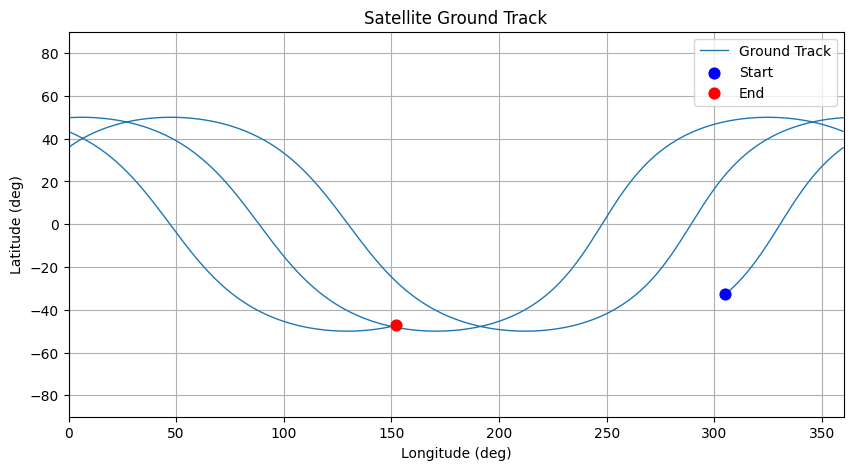

In [ ]:
lons = []
lats = []

for step in range((t_f)//dt):
    x, y, z = r_ECEF(start_date + np.timedelta64(step*dt, 's'))
    lons.append(np.degrees(np.arctan2(y,x)) % 360)
    lats.append(np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2))))

for i in range(1, len(lons)):
  if abs(lons[i] - lons[i-1]) > 180:
    lons[i] = np.nan
    lats[i] = np.nan

lon_i, lat_i = lons[0], lats[0]
lon_f, lat_f = lons[-1], lats[-1]

# Start and end points
plt.figure(figsize=(10,5))
plt.plot(lons, lats, linewidth=1, label="Ground Track")

plt.scatter(lon_i, lat_i, color='blue', s=60, zorder=5, label="Start")
plt.scatter(lon_f, lat_f, color='red', s=60, zorder=5, label="End")
plt.xlim(0, 360)
plt.ylim(-90, 90)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Satellite Ground Track")
plt.grid()
plt.legend()
plt.show()

In [ ]:
r1 = np.array([5000, 10000, 2199])
r2 = np.array([-14600, 2500, 7000])

r1_mag, r2_mag = mag(r1), mag(r2)
c = mag(r2 - r1)
s = (r1_mag + r2_mag + c) / 2
a_min = s / 2
delta_t = 3600

def _alpha(a):
    val = np.sqrt(np.clip(s / (2 * a), 0, 1))
    return 2 * np.arcsin(val)

def _beta(a):
    val = np.sqrt(np.clip((s - c) / (2 * a), 0, 1))
    hz_dir = np.cross(r1, r2)[2]
    # Logic: if delta_theta < pi, beta is positive.
    return 2 * np.arcsin(val) if hz_dir >= 0 else -2 * np.arcsin(val)

def a_error(a):
    alpha = _alpha(a)
    beta = _beta(a)

    sol = a**(1.5) * ((alpha - np.sin(alpha)) - (beta - np.sin(beta)))
    return sol - np.sqrt(mu) * delta_t

a = brentq(a_error, a_min+1e-4, 10*a_min)
alpha = _alpha(a)
beta = _beta(a)
delta_E = alpha - beta

#sanity check that a_min is indeed less than a
# print(a > a_min)

f = 1 - (a / r1_mag) * (1 - np.cos(delta_E))
g = delta_t - np.sqrt(a**3 / mu) * (delta_E - np.sin(delta_E))

v1 = (r2 - f*r1) / g
v1_mag = mag(v1)

In [ ]:
#specific ang. momentum
h = np.cross(r1, v1)

#eccentricity vector
e = 1/mu *((v1.dot(v1) - mu/mag(r1)) * r1 - (r1.dot(v1)) * v1 )

#node vector
n = np.array([-h[1], h[0], 0])

#inclination
i = np.arccos(h[2] / mag(h))

#magnitudes
h_mag = mag(h)
e_mag = mag(e)
n_mag = mag(n)

#Right Ascension of Ascending Node
RAAN_temp = np.arccos(n[0] / n_mag)
RAAN = RAAN_temp if n[1] > 0 else 2*np.pi - RAAN_temp

#Argument of Periapsis
peri_temp = np.arccos(n.dot(e) / (n_mag*e_mag))
ArgPeri = peri_temp if e[2] > 0 else 2*np.pi - peri_temp

#True anomaly
temp_nu = np.arccos(e.dot(r1)/(e_mag * mag(r1)))
nu = temp_nu if r1.dot(v1) > 0 else 2*np.pi - temp_nu

#Initial Eccentric Anomaly
E_0 = np.arccos((e_mag + np.cos(nu))/(1 + e_mag*np.cos(nu)))

#Semi-major axis
EN = mag(v1)**2 / 2 - mu / r0_mag
a = -mu / (2*EN)

#Initial Mean Anomaly
mean_motion = np.sqrt(mu / a**3)
M_0 = E_0 - e_mag*np.sin(E_0)

#Perigee altitude
r_p = a*(1-e_mag)
print(a)
print(e_mag)
print(np.degrees(i))
print(np.degrees(RAAN))
print(np.degrees(ArgPeri))
print(np.degrees(nu))
print(r_p)
print(v1)

18511.359750226362
0.4317234727914542
30.423562525986377
43.86696965783101
31.408097500499643
350.9940436769069
10519.571232766692
[-5.9902608   1.9007561   3.24250975]


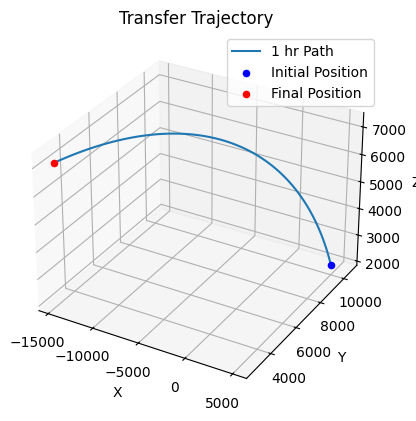

In [ ]:
def propagate_lambert(r1, v1, t_step, mu):
    M = M_0 + np.sqrt(mu / a**3) * t_step
    E = fsolve(lambda e_anom: e_anom - e_mag * np.sin(e_anom) - M, M)[0]

    # delta_E is change from initial E_0 to current E
    dE = E - E_0

    # Standard f and g functions for propagation
    f = 1 - (a / mag(r1)) * (1 - np.cos(dE))
    g = t_step - np.sqrt(a**3 / mu) * (dE - np.sin(dE))

    return f * r1 + g * v1

fg_coors = [propagate_lambert(r1, v1, t, mu) for t in np.linspace(0, delta_t, 100)]
traj, ax = traj_fig(fg_coors,"Transfer Trajectory","1 hr Path")
#it's understood that the final location is slightly off from r2 due to numerical errors
ax.scatter(*fg_coors[0], color='blue', marker='o', label='Initial Position')
ax.scatter(*fg_coors[-1], color='red', marker='o', label='Final Position')
ax.legend()

In [ ]:
# Initial angles on Jan 1, 2024 (rad)
rads_E0 = 1.7488
rads_V0 = 3.2511
t0 = datetime.datetime(2024, 1, 1)

#Values derived from handwork
omga_E = 1.990e-7
omga_V = 3.259e-7
phi_EV = -0.957
phi_VE = 0.631
t_H = 12576965.342

# Synodic period
T_syn = 2 * np.pi / abs(omga_V - omga_E)


#the remainder of this code takes heavy inspiration from Avaneesh as he
#helped walked me through writing the function and used his own as a reference
#all similarities are known and were discussed beforehand
def get_windows(phi_target, start_year, end_year):
  windows = []
  k = -5
  while True:
    t = (phi_target - (rads_V0 - rads_E0) + 2*np.pi*k) / (omga_V - omga_E)
    date = t0 + datetime.timedelta(seconds=t)
    if date.year > end_year:
      break
    if start_year <= date.year <= end_year:
      windows.append(date)
  k += 1
  return windows


EV_launches = get_windows(phi_EV, 2024, 2034)
VE_launches = get_windows(phi_VE, 2024, 2034)

print("Earth to Venus Hohmann Launch Windows:")
for d in EV_launches:
  arrival = d + datetime.timedelta(seconds=t_H)
  print(f"Launch: {d.date()} Arrival: {arrival.date()}")
  print("\nVenus to Earth Hohmann Launch Windows:")
for d in VE_launches:
  arrival = d + datetime.timedelta(seconds=t_H)
  print(f"Launch: {d.date()} Arrival: {arrival.date()}")

KeyboardInterrupt: 